# Observatorio de Educacion - Carga y Analisis de Datos

**Objetivo:** Cargar, explorar y analizar la calidad de los datos de cada fuente del Observatorio de Educacion de Cali.

**Fuentes de datos:**
1. Reporte de Matricula 2026
2. Indicadores de Eficiencia y Cobertura 2026
3. Estudiantes por Docente y Equipo de Computo 2026
4. Informacion Geografica de Sedes
5. Reporte de Inventario de Equipos de Computo
6. Intervenciones de Infraestructura (22 sedes, 49 sedes emprestito, historico obras)

**Metodologia:** Para cada fuente se analiza:
- Dimensiones (filas x columnas)
- Tipos de datos
- Valores nulos
- Valores vacios
- Registros duplicados
- Valores unicos por columna clave
- Estadisticas descriptivas

## Celda 0 - Configuracion del entorno

In [43]:
import os
import sys

# Detectar si estamos en Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Clonar repo si no existe
    REPO_URL = 'https://github.com/j0rg3c45/Observatorio_de_Educacion.git'
    REPO_DIR = '/content/Observatorio_de_Educacion'
    if not os.path.exists(REPO_DIR):
        os.system(f'git clone {REPO_URL} {REPO_DIR}')
    os.chdir(REPO_DIR)
    DATA_PATH = 'data/Fuentes de datos'
else:
    # Ejecucion local
    DATA_PATH = '../data/Fuentes de datos'

print(f'Entorno: {"Colab" if IN_COLAB else "Local"}')
print(f'Ruta de datos: {DATA_PATH}')
print(f'Directorio de trabajo: {os.getcwd()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Entorno: Colab
Ruta de datos: data/Fuentes de datos
Directorio de trabajo: /content/Observatorio_de_Educacion


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Configuracion de graficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Formato de numeros en pandas: separador de miles con punto
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:,.2f}'.format)


def fmt_num(valor):
    """Formatea numeros grandes: 1.5K, 2.3M, etc."""
    if abs(valor) >= 1_000_000:
        return f'{valor/1_000_000:.1f}M'
    elif abs(valor) >= 1_000:
        return f'{valor/1_000:.1f}K'
    else:
        return f'{valor:,.0f}'


def fmt_eje(ax, eje='x'):
    """Aplica formato abreviado (K, M) a un eje del grafico."""
    def _formatter(x, pos):
        if abs(x) >= 1_000_000:
            return f'{x/1_000_000:.1f}M'
        elif abs(x) >= 1_000:
            return f'{x/1_000:.0f}K'
        else:
            return f'{x:.0f}'
    if eje == 'x':
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(_formatter))
    else:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(_formatter))


print('Librerias cargadas correctamente (pandas, numpy, matplotlib, seaborn)')

Librerias cargadas correctamente (pandas, numpy, matplotlib, seaborn)


## Funcion auxiliar de analisis de calidad

In [45]:
def analisis_calidad(df, nombre_fuente):
    """Analiza la calidad de un DataFrame y muestra resumen completo."""
    print('=' * 70)
    print(f'ANALISIS DE CALIDAD: {nombre_fuente}')
    print('=' * 70)
    
    # Dimensiones
    print(f'\nDimensiones: {df.shape[0]:,} filas x {df.shape[1]:,} columnas')
    
    # Tipos de datos
    print(f'\nTipos de datos:')
    print(df.dtypes.value_counts().to_string())
    
    # Valores nulos
    nulos = df.isnull().sum()
    nulos_pct = (nulos / len(df) * 100).round(2)
    nulos_df = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_pct})
    nulos_df = nulos_df[nulos_df['Nulos'] > 0].sort_values('Nulos', ascending=False)
    
    if len(nulos_df) > 0:
        print(f'\nColumnas con valores nulos ({len(nulos_df)} de {df.shape[1]}):')
        display_nulos = nulos_df.copy()
        display_nulos['Nulos'] = display_nulos['Nulos'].apply(lambda x: f'{x:,}')
        print(display_nulos.to_string())
    else:
        print(f'\nValores nulos: NINGUNO')
    
    # Valores vacios (strings vacios)
    cols_obj = df.select_dtypes(include='object').columns
    if len(cols_obj) > 0:
        vacios = (df[cols_obj] == '').sum()
        vacios = vacios[vacios > 0]
        if len(vacios) > 0:
            print(f'\nColumnas con strings vacios:')
            print(vacios.to_string())
        else:
            print(f'\nStrings vacios: NINGUNO')
    
    # Duplicados
    duplicados = df.duplicated().sum()
    print(f'\nRegistros duplicados: {duplicados:,} ({duplicados/len(df)*100:.2f}%)')
    
    # Valores unicos por columna
    print(f'\nValores unicos por columna:')
    unicos = df.nunique()
    unicos_fmt = unicos.apply(lambda x: f'{x:,}')
    print(unicos_fmt.to_string())
    
    # Estadisticas descriptivas numericas
    cols_num = df.select_dtypes(include=[np.number]).columns
    if len(cols_num) > 0:
        print(f'\nEstadisticas descriptivas (columnas numericas):')
        desc = df[cols_num].describe()
        # Formatear con separador de miles
        print(desc.applymap(lambda x: f'{x:,.2f}').to_string())
    
    print('\n')
    return nulos_df

## Funcion auxiliar de visualizacion

In [46]:
def grafico_nulos(df, nombre_fuente, top_n=15):
    """Grafico de barras horizontales con las columnas con mas nulos."""
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0].sort_values(ascending=True).tail(top_n)
    
    if len(nulos) == 0:
        print(f'{nombre_fuente}: Sin valores nulos - no se genera grafico.')
        return
    
    fig, ax = plt.subplots(figsize=(9, max(3, len(nulos) * 0.4)))
    nulos.plot(kind='barh', ax=ax, color=sns.color_palette('Set2')[1])
    ax.set_xlabel('Cantidad de nulos')
    ax.set_title(f'Columnas con valores nulos - {nombre_fuente}')
    fmt_eje(ax, 'x')
    for i, v in enumerate(nulos.values):
        ax.text(v + max(nulos.values)*0.01, i, f'{fmt_num(v)} ({v/len(df)*100:.1f}%)', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()


def grafico_tipos_datos(df, nombre_fuente):
    """Grafico de torta con la distribucion de tipos de datos."""
    tipos = df.dtypes.value_counts()
    fig, ax = plt.subplots(figsize=(6, 4))
    tipos.plot(kind='pie', ax=ax, autopct='%1.0f%%', startangle=90)
    ax.set_ylabel('')
    ax.set_title(f'Tipos de datos - {nombre_fuente}')
    plt.tight_layout()
    plt.show()


def grafico_distribucion_numericas(df, nombre_fuente, max_cols=6):
    """Histogramas de las primeras columnas numericas con ejes formateados."""
    cols_num = df.select_dtypes(include=[np.number]).columns[:max_cols]
    if len(cols_num) == 0:
        return
    
    n_cols = min(3, len(cols_num))
    n_rows = (len(cols_num) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    if n_rows * n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(cols_num):
        axes[i].hist(df[col].dropna(), bins=20, color=sns.color_palette('Set2')[0], edgecolor='white')
        axes[i].set_title(col, fontsize=10)
        axes[i].set_xlabel('')
        fmt_eje(axes[i], 'x')
        fmt_eje(axes[i], 'y')
    
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    
    fig.suptitle(f'Distribucion de variables numericas - {nombre_fuente}', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


print('Funciones de visualizacion cargadas')

Funciones de visualizacion cargadas


---
## 1. Reporte de Matricula 2026

In [47]:
# Cargar matricula
ruta_matricula = os.path.join(DATA_PATH, 'Reporte de matr\u00edcula', '01_Matricula_2026.xlsx')

# Fallback sin tilde
if not os.path.exists(ruta_matricula):
    ruta_matricula = os.path.join(DATA_PATH, 'Reporte de matricula', '01_Matricula_2026.xlsx')

print(f'Cargando: {ruta_matricula}')
df_matricula = pd.read_excel(ruta_matricula)
print(f'Carga exitosa.')
df_matricula.head()

Cargando: data/Fuentes de datos/Reporte de matrícula/01_Matricula_2026.xlsx
Carga exitosa.


,sector,Matrícula
0,Oficial,143747
1,No oficial,159469
2,SGP Defensa,1075
3,Total,304291


In [48]:
# Analisis de calidad - Matricula
nulos_matricula = analisis_calidad(df_matricula, 'REPORTE DE MATRICULA 2026')

ANALISIS DE CALIDAD: REPORTE DE MATRICULA 2026

Dimensiones: 4 filas x 2 columnas

Tipos de datos:
object    1
int64     1

Valores nulos: NINGUNO

Strings vacios: NINGUNO

Registros duplicados: 0 (0.00%)

Valores unicos por columna:
sector       4
Matrícula    4

Estadisticas descriptivas (columnas numericas):
        Matrícula
count        4.00
mean   152,145.50
std    123,955.26
min      1,075.00
25%    108,079.00
50%    151,608.00
75%    195,674.50
max    304,291.00




In [49]:
# Columnas del dataset
print('Columnas disponibles:')
for i, col in enumerate(df_matricula.columns, 1):
    print(f'  {i:2d}. {col} ({df_matricula[col].dtype})')

Columnas disponibles:
   1. sector (object)
   2. Matrícula (int64)


Matricula 2026: Sin valores nulos - no se genera grafico.


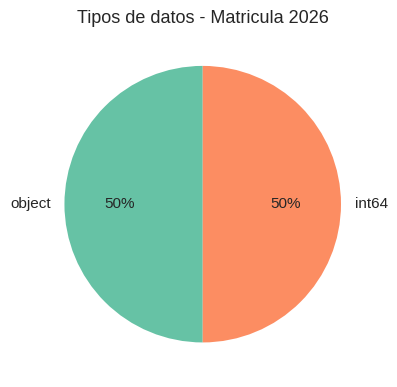

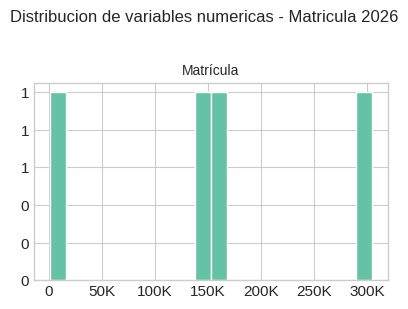

In [50]:
# Graficos - Matricula 2026
grafico_nulos(df_matricula, 'Matricula 2026')
grafico_tipos_datos(df_matricula, 'Matricula 2026')
grafico_distribucion_numericas(df_matricula, 'Matricula 2026')

---
## 2. Indicadores de Eficiencia y Cobertura 2026

In [51]:
# Cargar indicadores
ruta_indicadores = os.path.join(DATA_PATH, 'Indicadores de eficiencia y de cobertura', '02_Indicadores_2026.xlsx')
print(f'Cargando: {ruta_indicadores}')

df_indicadores = pd.read_excel(ruta_indicadores)
print(f'Carga exitosa.')
df_indicadores.head()

Cargando: data/Fuentes de datos/Indicadores de eficiencia y de cobertura/02_Indicadores_2026.xlsx
Carga exitosa.


,sector,Matrícula,Repitentes,Tasa de repitencia
0,Oficial,136644,12944,0.09
1,No oficial,144121,6273,0.04
2,SGP Defensa,1037,12,0.01
3,Total municipio,281802,19229,0.07


In [52]:
# Analisis de calidad - Indicadores
nulos_indicadores = analisis_calidad(df_indicadores, 'INDICADORES DE EFICIENCIA Y COBERTURA 2026')

ANALISIS DE CALIDAD: INDICADORES DE EFICIENCIA Y COBERTURA 2026

Dimensiones: 4 filas x 4 columnas

Tipos de datos:
int64      2
object     1
float64    1

Valores nulos: NINGUNO

Strings vacios: NINGUNO

Registros duplicados: 0 (0.00%)

Valores unicos por columna:
sector                4
Matrícula             4
Repitentes            4
Tasa de repitencia    4

Estadisticas descriptivas (columnas numericas):
        Matrícula Repitentes Tasa de repitencia
count        4.00       4.00               4.00
mean   140,901.00   9,614.50               0.05
std    114,664.03   8,304.57               0.04
min      1,037.00      12.00               0.01
25%    102,742.25   4,707.75               0.04
50%    140,382.50   9,608.50               0.06
75%    178,541.25  14,515.25               0.07
max    281,802.00  19,229.00               0.09




In [53]:
# Columnas del dataset
print('Columnas disponibles:')
for i, col in enumerate(df_indicadores.columns, 1):
    print(f'  {i:2d}. {col} ({df_indicadores[col].dtype})')

Columnas disponibles:
   1. sector (object)
   2. Matrícula (int64)
   3. Repitentes (int64)
   4. Tasa de repitencia (float64)


Indicadores 2026: Sin valores nulos - no se genera grafico.


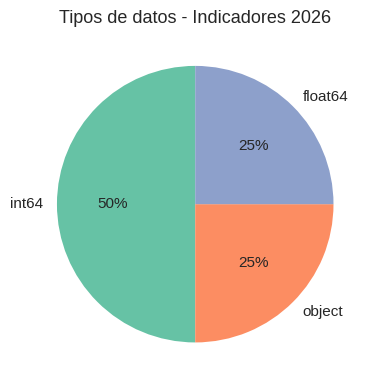

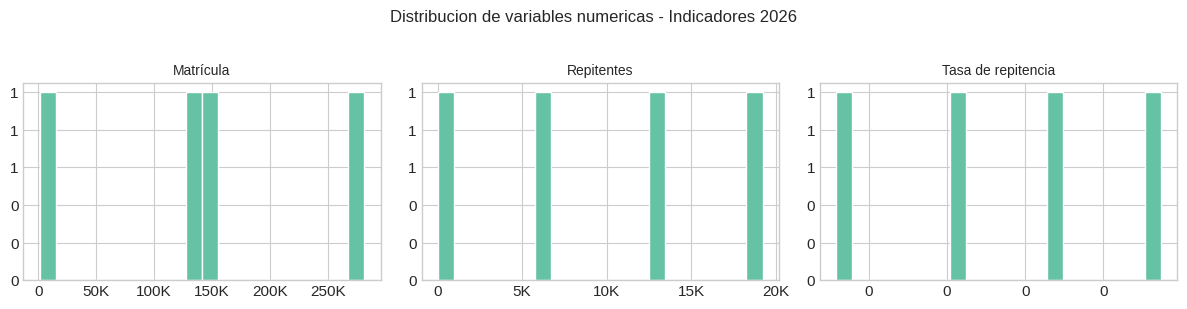

In [54]:
# Graficos - Indicadores 2026
grafico_nulos(df_indicadores, 'Indicadores 2026')
grafico_tipos_datos(df_indicadores, 'Indicadores 2026')
grafico_distribucion_numericas(df_indicadores, 'Indicadores 2026')

---
## 3. Estudiantes por Docente y Equipo de Computo 2026

In [55]:
# Cargar docentes y equipos
ruta_docentes = os.path.join(DATA_PATH, 'Indicadores de docentes y equipos de computo', '03_Estudiantes_por_docente_y_equipo_2026.xlsx')
print(f'Cargando: {ruta_docentes}')

df_docentes = pd.read_excel(ruta_docentes)
print(f'Carga exitosa.')
df_docentes.head()

Cargando: data/Fuentes de datos/Indicadores de docentes y equipos de computo/03_Estudiantes_por_docente_y_equipo_2026.xlsx
Carga exitosa.


,Indicador,Valor
0,Matrícula oficial (Marzo 2026),"143,747.00"
1,Docentes oficial (Marzo 2026),"5,835.00"
2,Estudiantes por docente (oficial),24.64
3,Equipos de cómputo en sedes oficiales,"29,432.00"
4,Estudiantes por equipo de cómputo,4.88


In [56]:
# Analisis de calidad - Docentes y equipos
nulos_docentes = analisis_calidad(df_docentes, 'ESTUDIANTES POR DOCENTE Y EQUIPO 2026')

ANALISIS DE CALIDAD: ESTUDIANTES POR DOCENTE Y EQUIPO 2026

Dimensiones: 5 filas x 2 columnas

Tipos de datos:
object     1
float64    1

Valores nulos: NINGUNO

Strings vacios: NINGUNO

Registros duplicados: 0 (0.00%)

Valores unicos por columna:
Indicador    5
Valor        5

Estadisticas descriptivas (columnas numericas):
            Valor
count        5.00
mean    35,808.70
std     61,547.08
min          4.88
25%         24.64
50%      5,835.00
75%     29,432.00
max    143,747.00




In [57]:
# Columnas del dataset
print('Columnas disponibles:')
for i, col in enumerate(df_docentes.columns, 1):
    print(f'  {i:2d}. {col} ({df_docentes[col].dtype})')

Columnas disponibles:
   1. Indicador (object)
   2. Valor (float64)


Docentes y Equipos 2026: Sin valores nulos - no se genera grafico.


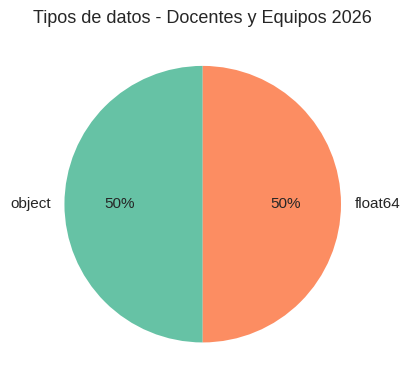

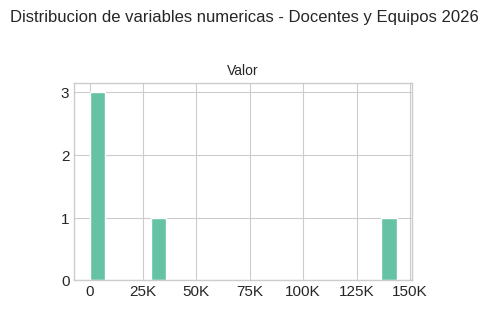

In [58]:
# Graficos - Docentes y Equipos 2026
grafico_nulos(df_docentes, 'Docentes y Equipos 2026')
grafico_tipos_datos(df_docentes, 'Docentes y Equipos 2026')
grafico_distribucion_numericas(df_docentes, 'Docentes y Equipos 2026')

---
## 4. Informacion Geografica de Sedes

In [59]:
# Cargar info geografica
ruta_geo = os.path.join(DATA_PATH, 'Informaci\u00f3n geogr\u00e1fica sedes.xlsx')

# Fallback sin tildes
if not os.path.exists(ruta_geo):
    ruta_geo = os.path.join(DATA_PATH, 'Informacion geografica sedes.xlsx')

print(f'Cargando: {ruta_geo}')
df_geo = pd.read_excel(ruta_geo)
print(f'Carga exitosa.')
df_geo.head()

Cargando: data/Fuentes de datos/Información geográfica sedes.xlsx
Carga exitosa.


,EeCodDane,EeNomIns,EeCoDanAnt,EeConSede,EeNomSede,EeClaSede,EeEstado,EeDirecc,EeNomCorto,EeEstado2,EEComCor,EEBarVer,EEFecAct,geometry
0,276001004889,Institucion Educativa El Hormiguero,276001005427,27600100488900,Sede Antonio Villavicencio,SEDE,OF,CORREGIMIENTO EL HORMIGUERO - CASA 203,SD Antonio Villavicencio,SEDOF,52,5201,2023-06-30,POINT (1066557.6023 858049.8995)
1,276001004889,Institucion Educativa El Hormiguero,276001004889,27600100488900,Institucion Educativa El Hormiguero - Pantano ...,PRIN,OF,CRA 143 - CALLE CASCAJAL 2-10 CASA 210,IE El Hormiguero,IEOOF,52,5205,2023-06-30,POINT (1064023.456 858486.8089)
2,276001004889,Institucion Educativa El Hormiguero,276001800481,27600100488900,Hogar Juvenil Campesino El Hormiguero,SEDE,OF,VDA CASCAJAL,SD Hogar Juvenil Campesino El Hormiguero,SEDOF,52,5205,2023-06-30,POINT (1064465.6319 858619.5539)
3,276001008574,Institucion Educativa Pance,276001007659,27600100857400,Laureano Gomez,SEDE,OF,VEREDA EL BANQUEO CORREGIMIENTO PANCE,SD Laureano Gomez,SEDOF,53,5306,2023-06-30,POINT (1053724.6258999999 859060.001)
4,276001008574,Institucion Educativa Pance,276001005231,27600100857400,República De Santo Domingo,SEDE,OF,CORREGIMIENTO PANCE PUEBLO PANCE,SD República De Santo Domingo,SEDOF,53,5301,2023-06-30,POINT (1049692.5568 859524.7439)


In [60]:
# Analisis de calidad - Info geografica
nulos_geo = analisis_calidad(df_geo, 'INFORMACION GEOGRAFICA DE SEDES')

ANALISIS DE CALIDAD: INFORMACION GEOGRAFICA DE SEDES

Dimensiones: 356 filas x 14 columnas

Tipos de datos:
object            8
int64             5
datetime64[ns]    1

Valores nulos: NINGUNO

Strings vacios: NINGUNO

Registros duplicados: 0 (0.00%)

Valores unicos por columna:
EeCodDane      96
EeNomIns       96
EeCoDanAnt    356
EeConSede      97
EeNomSede     348
EeClaSede       2
EeEstado        3
EeDirecc      349
EeNomCorto    347
EeEstado2       6
EEComCor       38
EEBarVer      211
EEFecAct        1
geometry      356

Estadisticas descriptivas (columnas numericas):
                EeCodDane          EeCoDanAnt              EeConSede EEComCor  EEBarVer
count              356.00              356.00                 356.00   356.00    356.00
mean   192,293,173,207.42  194,259,485,866.22  19,130,440,352,276.68    17.88  1,803.22
std     45,207,046,515.05   45,387,841,801.39   4,742,910,988,330.32    17.88  1,785.45
min    176,001,001,656.00  176,001,001,001.00                   0.00

In [61]:
# Columnas del dataset
print('Columnas disponibles:')
for i, col in enumerate(df_geo.columns, 1):
    print(f'  {i:2d}. {col} ({df_geo[col].dtype})')

Columnas disponibles:
   1. EeCodDane (int64)
   2. EeNomIns (object)
   3. EeCoDanAnt (int64)
   4. EeConSede (int64)
   5. EeNomSede (object)
   6. EeClaSede (object)
   7. EeEstado (object)
   8. EeDirecc (object)
   9. EeNomCorto (object)
  10. EeEstado2 (object)
  11. EEComCor (int64)
  12. EEBarVer (int64)
  13. EEFecAct (datetime64[ns])
  14. geometry (object)


Info Geografica Sedes: Sin valores nulos - no se genera grafico.


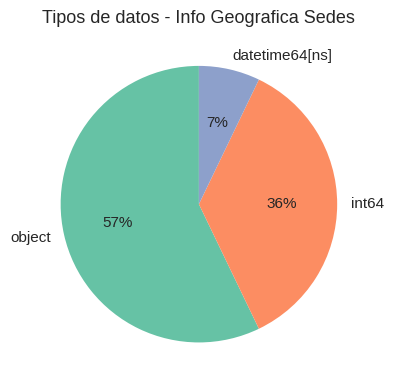

In [62]:
# Graficos - Info Geografica
grafico_nulos(df_geo, 'Info Geografica Sedes')
grafico_tipos_datos(df_geo, 'Info Geografica Sedes')

---
## 5. Reporte de Inventario de Equipos de Computo

In [63]:
# Cargar inventario equipos
ruta_equipos = os.path.join(DATA_PATH, 'REPORTE DE INVENTARIO DE EQUIPOS DE COMPUTO SEDES EDUCATIVAS.xlsx')
print(f'Cargando: {ruta_equipos}')

df_equipos = pd.read_excel(ruta_equipos)
print(f'Carga exitosa.')
df_equipos.head()

Cargando: data/Fuentes de datos/REPORTE DE INVENTARIO DE EQUIPOS DE COMPUTO SEDES EDUCATIVAS.xlsx
Carga exitosa.


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,NaN,NaN,NaN,NaN,NaN,FORMATO \nREPORTE DE INVENTARIO DE EQUIPOS DE ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
# Analisis de calidad - Equipos
nulos_equipos = analisis_calidad(df_equipos, 'INVENTARIO DE EQUIPOS DE COMPUTO')

ANALISIS DE CALIDAD: INVENTARIO DE EQUIPOS DE COMPUTO

Dimensiones: 2,014 filas x 22 columnas

Tipos de datos:
object     21
float64     1

Columnas con valores nulos (22 de 22):
             Nulos  Porcentaje (%)
Unnamed: 0   2,014          100.00
Unnamed: 2   1,667           82.77
Unnamed: 14  1,667           82.77
Unnamed: 17  1,667           82.77
Unnamed: 8   1,667           82.77
Unnamed: 6   1,667           82.77
Unnamed: 19  1,667           82.77
Unnamed: 20  1,666           82.72
Unnamed: 13  1,666           82.72
Unnamed: 4   1,666           82.72
Unnamed: 16  1,666           82.72
Unnamed: 11  1,666           82.72
Unnamed: 7   1,666           82.72
Unnamed: 9   1,666           82.72
Unnamed: 15  1,666           82.72
Unnamed: 12  1,665           82.67
Unnamed: 3   1,665           82.67
Unnamed: 5   1,665           82.67
Unnamed: 18  1,665           82.67
Unnamed: 10  1,665           82.67
Unnamed: 21     13            0.65
Unnamed: 1       9            0.45

Strings vacios:

In [65]:
# Columnas del dataset
print('Columnas disponibles:')
for i, col in enumerate(df_equipos.columns, 1):
    print(f'  {i:2d}. {col} ({df_equipos[col].dtype})')

Columnas disponibles:
   1. Unnamed: 0 (float64)
   2. Unnamed: 1 (object)
   3. Unnamed: 2 (object)
   4. Unnamed: 3 (object)
   5. Unnamed: 4 (object)
   6. Unnamed: 5 (object)
   7. Unnamed: 6 (object)
   8. Unnamed: 7 (object)
   9. Unnamed: 8 (object)
  10. Unnamed: 9 (object)
  11. Unnamed: 10 (object)
  12. Unnamed: 11 (object)
  13. Unnamed: 12 (object)
  14. Unnamed: 13 (object)
  15. Unnamed: 14 (object)
  16. Unnamed: 15 (object)
  17. Unnamed: 16 (object)
  18. Unnamed: 17 (object)
  19. Unnamed: 18 (object)
  20. Unnamed: 19 (object)
  21. Unnamed: 20 (object)
  22. Unnamed: 21 (object)


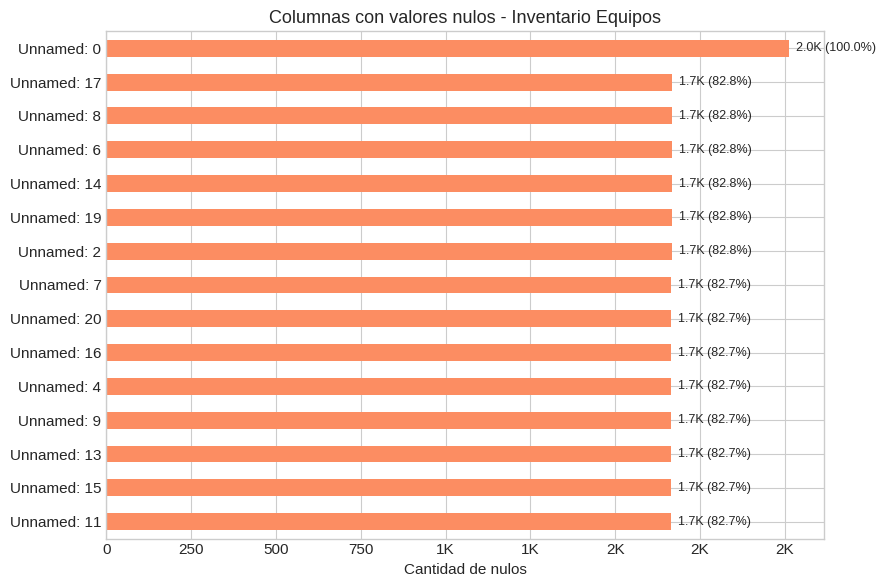

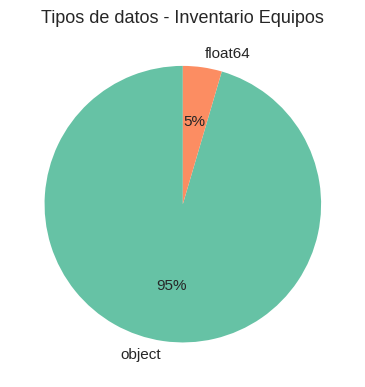

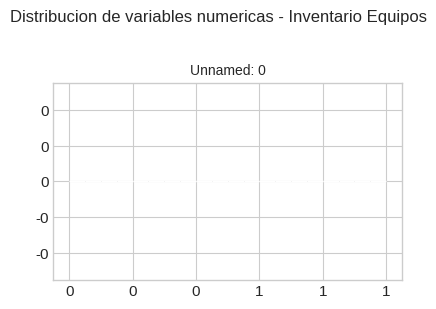

In [66]:
# Graficos - Inventario Equipos
grafico_nulos(df_equipos, 'Inventario Equipos')
grafico_tipos_datos(df_equipos, 'Inventario Equipos')
grafico_distribucion_numericas(df_equipos, 'Inventario Equipos')

---
## 6. Intervenciones de Infraestructura

### 6.1 - 22 Sedes con intervencion

In [67]:
# Cargar 22 sedes
ruta_22 = os.path.join(DATA_PATH, 'Intervenciones de infraestructura', '22 SEDES.xlsx')
print(f'Cargando: {ruta_22}')

df_22_sedes = pd.read_excel(ruta_22)
print(f'Carga exitosa.')
df_22_sedes.head()

Cargando: data/Fuentes de datos/Intervenciones de infraestructura/22 SEDES.xlsx
Carga exitosa.


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,OBRA,NaN,NaN,"2,025.00","2,026.00",TOTAL,SALDO,NaN,NaN,NaN
2,NaN,NaN,NaN,LOTE 1,"2,709,591,630.00",0.29,"945,986,179.00","1,619,416,206.00",2565402385,144189245,NaN,963783683,"-17,797,504.00"
3,NaN,NaN,NaN,LOTE 2,"2,340,696,555.00",0.25,"817,195,686.00","1,352,474,439.00",2169670125,171026430,NaN,815112934,"2,082,752.00"
4,NaN,NaN,NaN,LOTE 3,"2,282,860,712.00",0.24,"797,003,747.00","1,247,069,881.00",2044073628,238787084,NaN,767928190,"29,075,557.00"


In [68]:
# Analisis de calidad - 22 sedes
nulos_22 = analisis_calidad(df_22_sedes, '22 SEDES CON INTERVENCION')

ANALISIS DE CALIDAD: 22 SEDES CON INTERVENCION

Dimensiones: 19 filas x 13 columnas

Tipos de datos:
float64    9
object     4

Columnas con valores nulos (13 de 13):
            Nulos  Porcentaje (%)
Unnamed: 0     19          100.00
Unnamed: 1     19          100.00
Unnamed: 2     19          100.00
Unnamed: 10    17           89.47
Unnamed: 12    15           78.95
Unnamed: 5     13           68.42
Unnamed: 11    13           68.42
Unnamed: 4     11           57.89
Unnamed: 3     11           57.89
Unnamed: 9     11           57.89
Unnamed: 7      5           26.32
Unnamed: 8      5           26.32
Unnamed: 6      4           21.05

Strings vacios: NINGUNO

Registros duplicados: 3 (15.79%)

Valores unicos por columna:
Unnamed: 0      0
Unnamed: 1      0
Unnamed: 2      0
Unnamed: 3      6
Unnamed: 4      8
Unnamed: 5      6
Unnamed: 6     14
Unnamed: 7     13
Unnamed: 8     13
Unnamed: 9      7
Unnamed: 10     2
Unnamed: 11     6
Unnamed: 12     4

Estadisticas descriptivas (columna

### 6.2 - 49 Sedes Emprestito (Valores 2026 y 2027)

In [69]:
# Cargar 49 sedes emprestito
ruta_49 = os.path.join(DATA_PATH, 'Intervenciones de infraestructura', '49 sedes Empr\u00e9stito - Valores 2026 y 2027.xlsx')

if not os.path.exists(ruta_49):
    # Buscar archivo con nombre similar
    carpeta_infra = os.path.join(DATA_PATH, 'Intervenciones de infraestructura')
    archivos = [a for a in os.listdir(carpeta_infra) if '49' in a]
    if archivos:
        ruta_49 = os.path.join(carpeta_infra, archivos[0])

print(f'Cargando: {ruta_49}')
df_49_sedes = pd.read_excel(ruta_49)
print(f'Carga exitosa.')
df_49_sedes.head()

Cargando: data/Fuentes de datos/Intervenciones de infraestructura/49 sedes Empréstito - Valores 2026 y 2027.xlsx
Carga exitosa.


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Valor Obra 2026,NaN,NaN,Valor Interventoria 2026,NaN,NaN,Estudios y Diseños 2026,Valores 2027,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19213700115,NaN,NaN,1667399885,NaN,NaN,718900000,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lote 1 - Obra,Lote 2 - Obra,Total Obra,Lote 1 - Interventoria,Lote 2 - Interventoria,NaN,NaN,Obra,"4,909,090,909.00",NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12108292912,"12,014,498,111.90","24,122,791,023.90",1083289773,1074605250,2157895023,NaN,Interventoria,"490,495,138.00",NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.50,0.50,NaN,0.50,0.50,NaN,NaN,Total,"5,399,586,047.00",NaN,NaN,NaN


In [70]:
# Analisis de calidad - 49 sedes
nulos_49 = analisis_calidad(df_49_sedes, '49 SEDES EMPRESTITO - VALORES 2026 Y 2027')

ANALISIS DE CALIDAD: 49 SEDES EMPRESTITO - VALORES 2026 Y 2027

Dimensiones: 66 filas x 20 columnas

Tipos de datos:
object     15
float64     5

Columnas con valores nulos (20 de 20):
            Nulos  Porcentaje (%)
Unnamed: 0     66          100.00
Unnamed: 18    63           95.45
Unnamed: 19    60           90.91
Unnamed: 17    17           25.76
Unnamed: 1     16           24.24
Unnamed: 2     16           24.24
Unnamed: 3     13           19.70
Unnamed: 5     13           19.70
Unnamed: 7     13           19.70
Unnamed: 6     13           19.70
Unnamed: 4     12           18.18
Unnamed: 13    11           16.67
Unnamed: 14    11           16.67
Unnamed: 16    10           15.15
Unnamed: 10    10           15.15
Unnamed: 9      9           13.64
Unnamed: 15     8           12.12
Unnamed: 12     8           12.12
Unnamed: 11     7           10.61
Unnamed: 8      6            9.09

Strings vacios: NINGUNO

Registros duplicados: 0 (0.00%)

Valores unicos por columna:
Unnamed: 0    

### 6.3 - Historico de Obras 2020-2025

In [71]:
# Cargar historico obras
ruta_historico = os.path.join(DATA_PATH, 'Intervenciones de infraestructura', 'HISTORICO OBRAS 2020-2025.xlsx')
print(f'Cargando: {ruta_historico}')

df_historico = pd.read_excel(ruta_historico)
print(f'Carga exitosa.')
df_historico.head()

Cargando: data/Fuentes de datos/Intervenciones de infraestructura/HISTORICO OBRAS 2020-2025.xlsx
Carga exitosa.


,Subsecretaria de Planeación Sectorial,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,Infraestructura Educativa 2020-2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Año,IEO,Sede,Com,Estudiantes,Comuna,Proyecto,Valor obra,Valor interventoria,Valor estudios y diseños,Inversion,# Contrato obra,Contratista obra,Contrato interventoria,Contratista de interventoria,Contrato estudios y diseños,Contratista de estudios y diseños,Actividad principal
2,1,2020,INSTITUCION EDUCATIVA JOSE HOLGUIN GARCES,VILLA DEL MAR,1,167,Comuna 1 (uno),BP-26001704,42857143,2142858,NaN,45000001,4143.010.26.1.1467-2020,ANGGY NICOLS ACOSTA VELA,4143.010.26.1.1468-2020,ANDRES MAURICIO CARDOZO ROA,NaN,NaN,Baterías sanitarias de preescolar \n Pintura y...
3,2,2020,INSTITUCION EDUCATIVA VILLACOLOMBIA,INSTITUCION EDUCATIVA VILLACOLOMBIA,8,753,Comuna 8 (ocho),BP-26001749,94581823,4761905,NaN,99343728,4143.010.26.1.1485-2020,CONSORCIO D&C,4143.010.26.1.1486-2020,CONSORCIO EDUCATIVO DF,NaN,NaN,Adecuación de placa deportiva y andenes
4,3,2020,INSTITUCION EDUCATIVA JOAQUIN DE CAYCEDO Y CUERO,CAMILO TORRES,19,484,Comuna 19 (diecinueve),BP-26001340,3235880815,162821243,NaN,3398702058,SEM-IF-4143.010.26.1.1542-2020,CONSORCIO INCETELCA J.J. 250,4143.010.26.1.1476-2020,GPM PROYECTOS DE INGENIERIA S.A.S.,NaN,NaN,"Construcción de restaurante y comedor escolar,..."


In [72]:
# Analisis de calidad - Historico obras
nulos_historico = analisis_calidad(df_historico, 'HISTORICO OBRAS 2020-2025')

ANALISIS DE CALIDAD: HISTORICO OBRAS 2020-2025

Dimensiones: 480 filas x 19 columnas

Tipos de datos:
object    19

Columnas con valores nulos (19 de 19):
                                      Nulos  Porcentaje (%)
Unnamed: 16                             475           98.96
Unnamed: 17                             475           98.96
Unnamed: 10                             473           98.54
Unnamed: 9                              299           62.29
Unnamed: 15                             295           61.46
Unnamed: 14                             294           61.25
Unnamed: 13                              30            6.25
Unnamed: 12                              30            6.25
Unnamed: 8                               29            6.04
Unnamed: 5                               26            5.42
Subsecretaria de Planeación Sectorial    24            5.00
Unnamed: 6                               24            5.00
Unnamed: 4                               24            5.00
Unnam

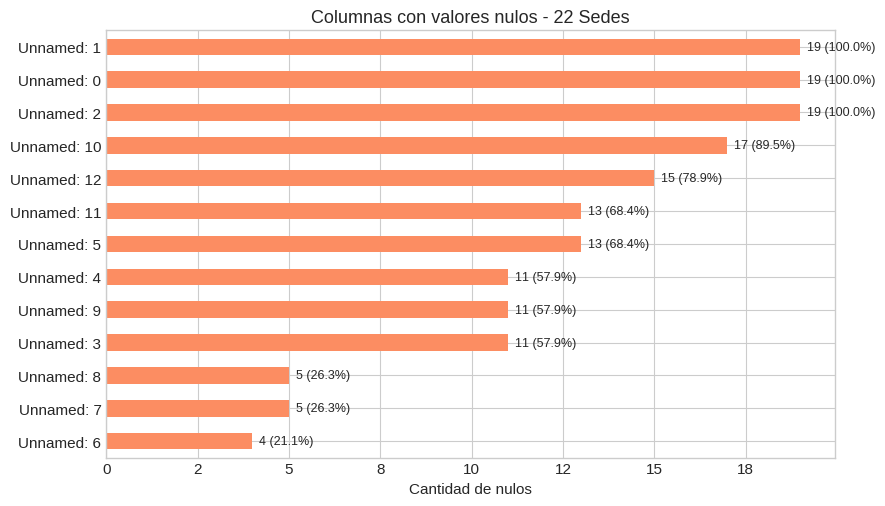

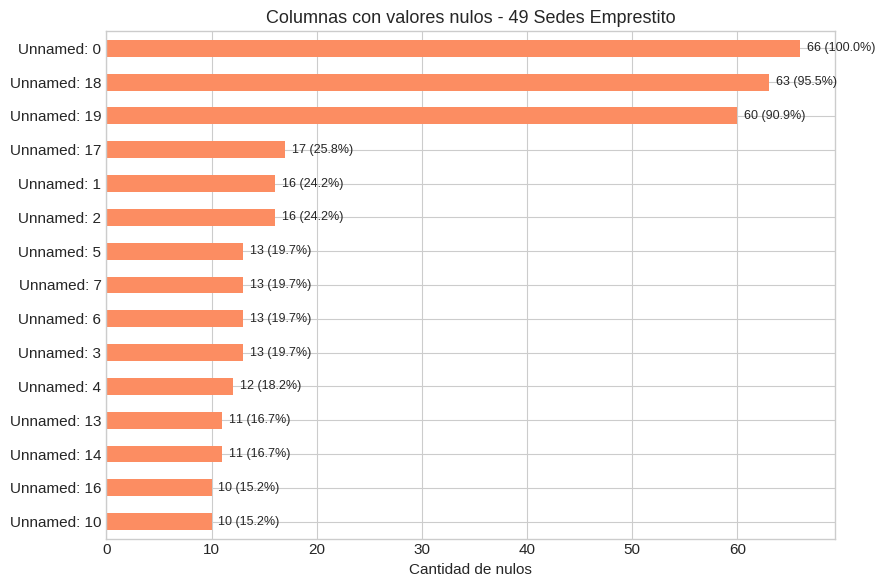

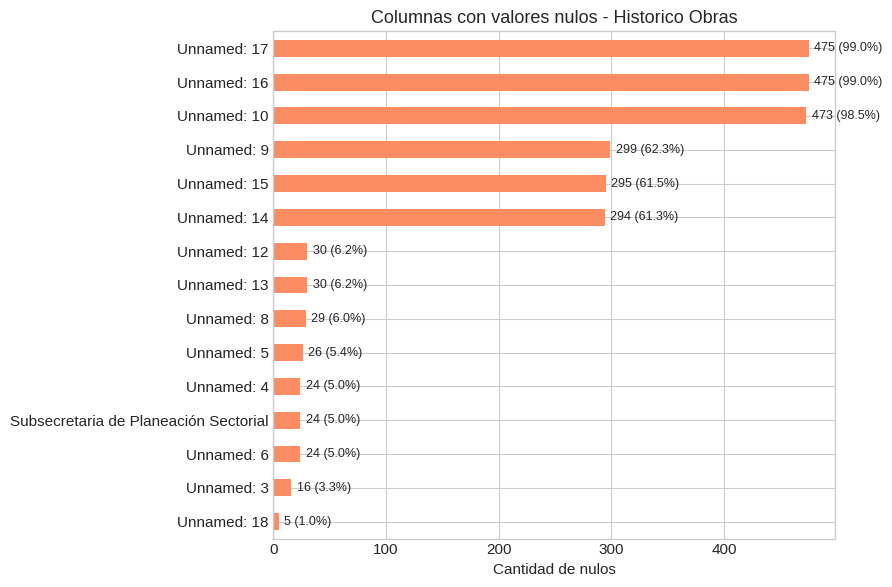

In [73]:
# Graficos - Infraestructura consolidado
grafico_nulos(df_22_sedes, '22 Sedes')
grafico_nulos(df_49_sedes, '49 Sedes Emprestito')
grafico_nulos(df_historico, 'Historico Obras')
grafico_distribucion_numericas(df_historico, 'Historico Obras 2020-2025')

---
## 7. Resumen consolidado de calidad de datos

In [74]:
# Resumen consolidado
resumen = pd.DataFrame({
    'Fuente': [
        'Matricula 2026',
        'Indicadores Eficiencia/Cobertura 2026',
        'Estudiantes por Docente/Equipo 2026',
        'Informacion Geografica Sedes',
        'Inventario Equipos Computo',
        '22 Sedes Intervencion',
        '49 Sedes Emprestito',
        'Historico Obras 2020-2025'
    ],
    'Filas': [
        len(df_matricula),
        len(df_indicadores),
        len(df_docentes),
        len(df_geo),
        len(df_equipos),
        len(df_22_sedes),
        len(df_49_sedes),
        len(df_historico)
    ],
    'Columnas': [
        df_matricula.shape[1],
        df_indicadores.shape[1],
        df_docentes.shape[1],
        df_geo.shape[1],
        df_equipos.shape[1],
        df_22_sedes.shape[1],
        df_49_sedes.shape[1],
        df_historico.shape[1]
    ],
    'Nulos_Total': [
        df_matricula.isnull().sum().sum(),
        df_indicadores.isnull().sum().sum(),
        df_docentes.isnull().sum().sum(),
        df_geo.isnull().sum().sum(),
        df_equipos.isnull().sum().sum(),
        df_22_sedes.isnull().sum().sum(),
        df_49_sedes.isnull().sum().sum(),
        df_historico.isnull().sum().sum()
    ],
    'Duplicados': [
        df_matricula.duplicated().sum(),
        df_indicadores.duplicated().sum(),
        df_docentes.duplicated().sum(),
        df_geo.duplicated().sum(),
        df_equipos.duplicated().sum(),
        df_22_sedes.duplicated().sum(),
        df_49_sedes.duplicated().sum(),
        df_historico.duplicated().sum()
    ]
})

resumen['Pct_Nulos'] = (resumen['Nulos_Total'] / (resumen['Filas'] * resumen['Columnas']) * 100).round(2)

# Mostrar con formato legible
print('=' * 70)
print('RESUMEN CONSOLIDADO DE CALIDAD DE DATOS')
print('=' * 70)
display_resumen = resumen.copy()
display_resumen['Filas'] = display_resumen['Filas'].apply(lambda x: f'{x:,}')
display_resumen['Nulos_Total'] = display_resumen['Nulos_Total'].apply(lambda x: f'{x:,}')
display_resumen['Duplicados'] = display_resumen['Duplicados'].apply(lambda x: f'{x:,}')
display_resumen['Pct_Nulos'] = display_resumen['Pct_Nulos'].apply(lambda x: f'{x:.2f}%')
print(display_resumen.to_string(index=False))

RESUMEN CONSOLIDADO DE CALIDAD DE DATOS
                               Fuente Filas  Columnas Nulos_Total Duplicados Pct_Nulos
                       Matricula 2026     4         2           0          0     0.00%
Indicadores Eficiencia/Cobertura 2026     4         4           0          0     0.00%
  Estudiantes por Docente/Equipo 2026     5         2           0          0     0.00%
         Informacion Geografica Sedes   356        14           0          0     0.00%
           Inventario Equipos Computo 2,014        22      33,691          6    76.04%
                22 Sedes Intervencion    19        13         162          3    65.59%
                  49 Sedes Emprestito    66        20         382          0    28.94%
            Historico Obras 2020-2025   480        19       2,533          0    27.77%


---
## 8. Visualizaciones consolidadas

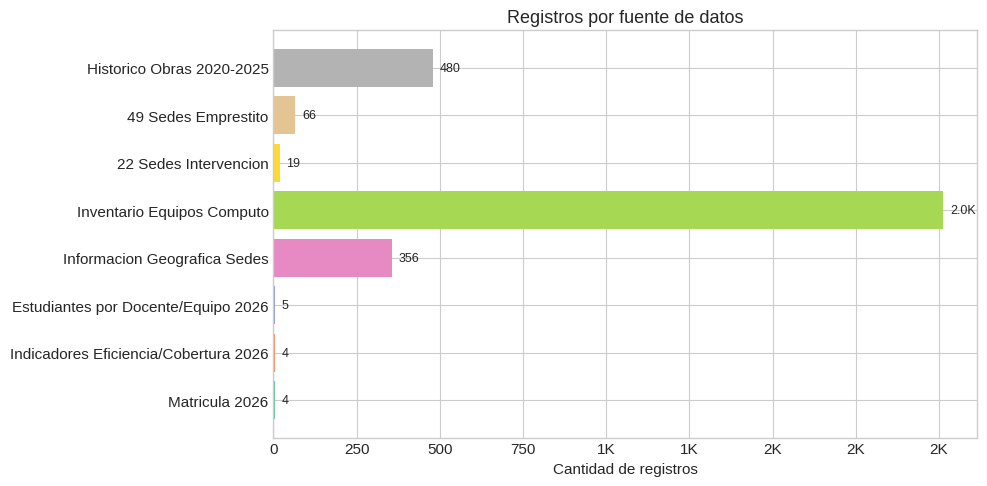

In [75]:
# Grafico 1: Registros por fuente (barras)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(resumen['Fuente'], resumen['Filas'], color=sns.color_palette('Set2'))
ax.set_xlabel('Cantidad de registros')
ax.set_title('Registros por fuente de datos')
fmt_eje(ax, 'x')
for bar in bars:
    width = bar.get_width()
    ax.text(width + max(resumen['Filas'])*0.01, bar.get_y() + bar.get_height()/2,
            fmt_num(width), va='center', fontsize=9)
plt.tight_layout()
plt.show()

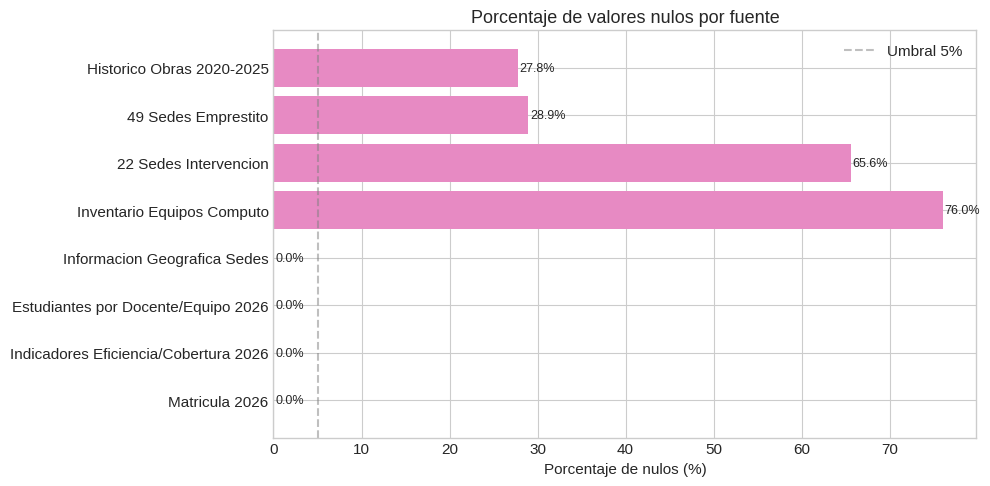

In [76]:
# Grafico 2: Porcentaje de nulos por fuente
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#66c2a5' if x < 5 else '#fc8d62' if x < 20 else '#e78ac3' for x in resumen['Pct_Nulos']]
bars = ax.barh(resumen['Fuente'], resumen['Pct_Nulos'], color=colors)
ax.set_xlabel('Porcentaje de nulos (%)')
ax.set_title('Porcentaje de valores nulos por fuente')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.5, label='Umbral 5%')
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}%', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

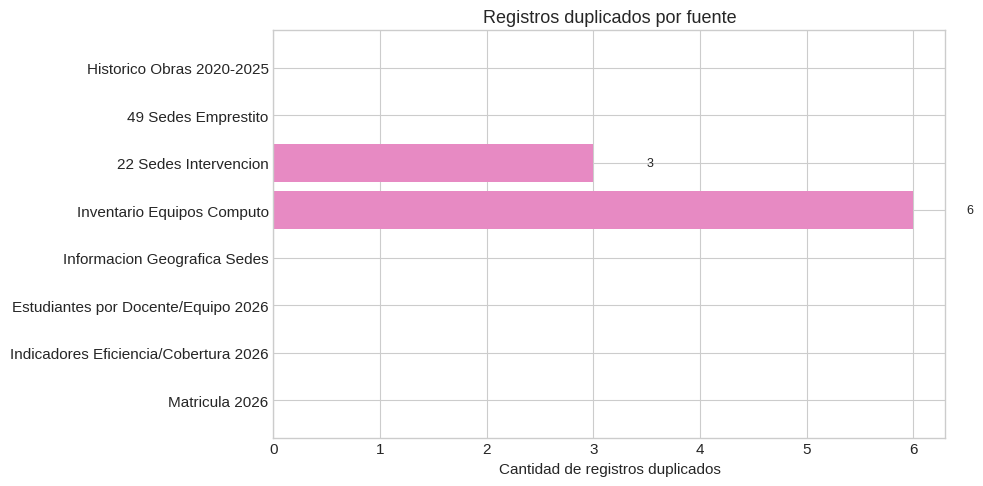

In [77]:
# Grafico 3: Duplicados por fuente
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(resumen['Fuente'], resumen['Duplicados'], color=sns.color_palette('Set2')[3])
ax.set_xlabel('Cantidad de registros duplicados')
ax.set_title('Registros duplicados por fuente')
for bar in bars:
    width = bar.get_width()
    if width > 0:
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                f'{int(width)}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

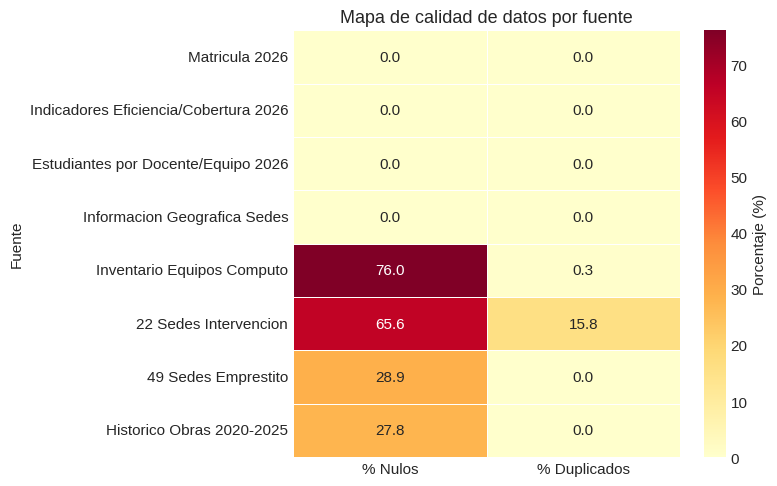

In [78]:
# Grafico 4: Resumen visual de calidad (heatmap simplificado)
calidad_matrix = resumen[['Fuente', 'Pct_Nulos', 'Duplicados']].copy()
calidad_matrix['Pct_Duplicados'] = (resumen['Duplicados'] / resumen['Filas'] * 100).round(2)
calidad_matrix = calidad_matrix.set_index('Fuente')[['Pct_Nulos', 'Pct_Duplicados']]
calidad_matrix.columns = ['% Nulos', '% Duplicados']

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(calidad_matrix, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Porcentaje (%)'})
ax.set_title('Mapa de calidad de datos por fuente')
plt.tight_layout()
plt.show()

---
## 9. Conclusiones del analisis exploratorio

Completar despues de ejecutar todas las celdas con las observaciones principales:

- **Matricula:** [observaciones]
- **Indicadores:** [observaciones]
- **Docentes/Equipos:** [observaciones]
- **Info Geografica:** [observaciones]
- **Inventario Equipos:** [observaciones]
- **Infraestructura:** [observaciones]

### Proximos pasos
1. Estandarizar nombres de sedes/IE entre fuentes
2. Cruzar datos con informacion geografica
3. Calcular indicadores derivados para el ICET
4. Normalizar con ref_min/ref_max fijos
5. Generar visualizaciones territoriales (mapas por comuna)